# Instalando Pacotes

In [2]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
import sklearn
from sklearn.preprocessing import StandardScaler
# Modelos de classificação
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
# XGBoost
from xgboost import XGBClassifier
# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

## Carregando dados

In [4]:
df_treino = pd.read_csv('dados/dados_treino.csv')

df_treino_final = pd.read_csv('dados/dados_treino_final.csv')

df_teste = pd.read_csv('dados/dados_teste.csv')

df_valid = pd.read_csv('dados/dados_teste.csv')



In [5]:
# Carregando colunas

with open('dados/colunas_entrada.sav','rb') as file:
    colunas_entrada=pickle.load(file)

In [6]:
df_treino.shape

(8050, 179)

In [7]:
# Preparando as matrizes

# Matrizes x
x_treino = df_treino_final[colunas_entrada].values
x_valid= df_valid[colunas_entrada].values
x_teste = df_teste[colunas_entrada].values

#Matrizes y

y_treino = df_treino_final['LABEL_TARGET'].values
y_valid = df_valid['LABEL_TARGET'].values
y_teste = df_teste['LABEL_TARGET'].values

In [8]:
print(f"Dados de Treino: {x_treino.shape},{y_treino.shape}")
print(f"Dados de Teste: {x_teste.shape},{y_teste.shape}")
print(f"Dados de Validação: {x_valid.shape},{y_valid.shape}")

Dados de Treino: (3244, 178),(3244,)
Dados de Teste: (1725, 178),(1725,)
Dados de Validação: (1725, 178),(1725,)


# Padronização dos dados



In [10]:
scaler = StandardScaler()

#Fit

scaler.fit(x_treino)

# Salva o objeto em disco

scalerfile = 'dados/scaler.sav'
pickle.dump(scaler,open(scalerfile,'wb'))


# Carrega o Scaler(padronizador)

scaler = pickle.load(open(scalerfile, 'rb'))

#Aplicando a padronização

x_treino_tf = scaler.transform(x_treino)
x_valid_tf = scaler.transform(x_valid)


# Funções Auxiliares 

In [12]:
def especificidade(y_actual, y_pred, thresh):
    return sum ((y_pred < thresh) & (y_actual == 0)) / sum (y_actual ==0)

In [13]:
# função relatorio de metricas

def print_relatorio(y_actual, y_pred, thresh):
    
    auc = roc_auc_score(y_actual, y_pred)
    acuracia = accuracy_score(y_actual, (y_pred > thresh))
    recall = recall_score(y_actual, (y_pred > thresh))
    precisao = precision_score(y_actual, (y_pred > thresh))
    esp = especificidade(y_actual, y_pred, thresh)
    
    print(f"AUC:             {auc:.3f}")
    print(f"Acurácia:        {acuracia:.3f}")
    print(f"Recall:          {recall:.3f}")
    print(f"Precisão:        {precisao:.3f}")
    print(f"Especificidade:  {esp:.3f}")
    print(' ')

    return acuracia, auc, recall, precisao, esp

In [14]:
thresh = 0.5

# Versão do Modelo 1 : Regressão Logistica (Baseline sem Hiperparâmetros)

In [16]:
# Criando o objeto
lr1 = LogisticRegression()

# Treinando o modelo
modelo_v1 = lr1.fit(x_treino_tf,y_treino)

#Previsões

y_train_preds = modelo_v1.predict_proba(x_treino_tf)[:,1]
y_valid_preds = modelo_v1.predict_proba(x_valid_tf)[:,1]

print('Modelo de Regressão Logistica: (sem Hiperparâmetros)')


print('\nTreinamento')


(
    lr1_acuracia_treino,
    lr1_auc_treino,
    lr1_recall_treino,
    lr1_precisao_treino,
    lr1_especificidade_treino
) = print_relatorio(
    y_treino,
    y_train_preds,
    thresh
)


# Métricas de validação
print("\nValidação")

(
    lr1_acuracia_validacao,
    lr1_auc_validacao,
    lr1_recall_validacao,
    lr1_precisao_validacao,
    lr1_especificidade_validacao
) = print_relatorio(
    y_valid,
    y_valid_preds,
    thresh
)


Modelo de Regressão Logistica: (sem Hiperparâmetros)

Treinamento
AUC:             0.626
Acurácia:        0.649
Recall:          0.528
Precisão:        0.697
Especificidade:  0.771
 

Validação
AUC:             0.496
Acurácia:        0.681
Recall:          0.432
Precisão:        0.298
Especificidade:  0.744
 


**Avaliação do modelo baseline**

_O modelo de Regressão Logística sem ajuste de hiperparâmetros foi utilizado como baseline para comparação com os demais modelos. No conjunto de treinamento, apresentou AUC de 0,626 e acurácia de 0,649, com melhor desempenho na identificação da classe negativa, evidenciado pela especificidade de 0,771._

_Na validação, a acurácia aumentou para 0,681 e a especificidade permaneceu relativamente alta, em 0,744. Entretanto, a AUC de 0,496 indica que o modelo apresentou baixa capacidade de discriminação entre as classes. Além disso, os valores de recall de 0,432 e precisão de 0,298 mostram dificuldade na identificação correta da classe positiva. Esses resultados sugerem que o modelo baseline possui desempenho limitado e pode ser melhorado com ajuste de hiperparâmetros, tratamento do desbalanceamento das classes e comparação com outros algoritmos._

# Versão do Modelo 2 - Regressão Logistica com Parâmetros 

In [19]:

# Criando o objeto
lr2 = LogisticRegression(
    penalty="l2",
    C=0.1,
    solver="liblinear",
    random_state=42,
    max_iter=1000
)


# Treinando o modelo
modelo_v2 = lr2.fit(x_treino_tf,y_treino)

#Previsões

y_train_preds = modelo_v2.predict_proba(x_treino_tf)[:,1]
y_valid_preds = modelo_v2.predict_proba(x_valid_tf)[:,1]

print('Modelo de Regressão Logistica: (Com Hiperparâmetros)')


print('\nTreinamento')


(
    lr2_acuracia_treino,
    lr2_auc_treino,
    lr2_recall_treino,
    lr2_precisao_treino,
    lr2_especificidade_treino
) = print_relatorio(
    y_treino,
    y_train_preds,
    thresh
)


# Métricas de validação
print("\nValidação")

(
    lr2_acuracia_validacao,
    lr2_auc_validacao,
    lr2_recall_validacao,
    lr2_precisao_validacao,
    lr2_especificidade_validacao
) = print_relatorio(
    y_valid,
    y_valid_preds,
    thresh
)

Modelo de Regressão Logistica: (Com Hiperparâmetros)

Treinamento
AUC:             0.598
Acurácia:        0.628
Recall:          0.513
Precisão:        0.667
Especificidade:  0.744
 

Validação
AUC:             0.496
Acurácia:        0.658
Recall:          0.429
Precisão:        0.275
Especificidade:  0.716
 


### Avaliação do Modelo 2 — Regressão Logística com Hiperparâmetros

Na segunda versão da regressão logística, foi aplicada regularização L2 com `C=0.1`, utilizando o solver `liblinear`. A redução do parâmetro `C` aumentou a força da regularização, com o objetivo de diminuir o sobreajuste observado no modelo inicial e melhorar sua capacidade de generalização.

No conjunto de treinamento, o modelo apresentou AUC de 0,598, acurácia de 0,628, recall de 0,513, precisão de 0,667 e especificidade de 0,744. Em comparação com o modelo inicial, houve redução da AUC de treinamento, indicando que a regularização tornou o modelo mais restritivo.

Entretanto, no conjunto de validação, a AUC permaneceu em 0,496, valor muito próximo de 0,50, que representa um desempenho semelhante ao de uma classificação aleatória. Além disso, a acurácia caiu para 0,658, a precisão para 0,275 e a especificidade para 0,716. O recall apresentou pouca alteração, passando para 0,429.

Esses resultados indicam que o aumento da regularização não melhorou a capacidade de generalização da regressão logística. Embora o modelo tenha se tornado menos ajustado aos dados de treinamento, não houve ganho de desempenho nos dados de validação. Isso sugere que o problema pode não estar apenas relacionado ao sobreajuste ou à escolha dos hiperparâmetros, mas também à dificuldade da regressão logística em capturar os padrões presentes nos dados.

Diante disso, será testada uma nova família de algoritmos, o Naive Bayes. Esse modelo utiliza uma abordagem probabilística e assume independência condicional entre as variáveis preditoras. Apesar dessa simplificação, ele pode apresentar bons resultados em conjuntos de dados pequenos, além de possuir baixo custo computacional e treinamento rápido.

O objetivo dessa mudança é verificar se uma abordagem probabilística consegue identificar relações entre as variáveis e a variável-alvo que não foram adequadamente capturadas pela regressão logística.


# Versão 3 Modelo - Naive Bayes

In [22]:

# Criando o objeto com parâmetros padrão
nb1 = GaussianNB()


# Treinando o modelo
modelo_v3 = nb1.fit(x_treino_tf,y_treino)

#Previsões

y_train_preds = modelo_v3.predict_proba(x_treino_tf)[:,1]
y_valid_preds = modelo_v3.predict_proba(x_valid_tf)[:,1]


print('Modelo Naive Bayes: (Sem Hiperparâmetros)')


print('\nTreinamento')


(
    nb1_acuracia_treino,
    nb1_auc_treino,
    nb1_recall_treino,
    nb1_precisao_treino,
    nb1_especificidade_treino
) = print_relatorio(
    y_treino,
    y_train_preds,
    thresh
)


# Métricas de validação
print("\nValidação")

(
    nb1_acuracia_validacao,
    nb1_auc_validacao,
    nb1_recall_validacao,
    nb1_precisao_validacao,
    nb1_especificidade_validacao
) = print_relatorio(
    y_valid,
    y_valid_preds,
    thresh
)

Modelo Naive Bayes: (Sem Hiperparâmetros)

Treinamento
AUC:             0.982
Acurácia:        0.932
Recall:          0.892
Precisão:        0.970
Especificidade:  0.972
 

Validação
AUC:             0.983
Acurácia:        0.954
Recall:          0.888
Precisão:        0.883
Especificidade:  0.970
 


### Avaliação do Modelo 3 — Gaussian Naive Bayes

Na terceira versão, foi avaliado o algoritmo Gaussian Naive Bayes com seus parâmetros padrão. A mudança de família teve como objetivo verificar se uma abordagem probabilística conseguiria representar melhor os padrões dos dados do que a regressão logística.

O modelo apresentou resultados expressivamente superiores aos observados nas duas versões da regressão logística. No conjunto de treinamento, foram obtidos AUC de 0,982, acurácia de 0,932, recall de 0,892, precisão de 0,970 e especificidade de 0,972.

No conjunto de validação, o modelo alcançou AUC de 0,983, acurácia de 0,954, recall de 0,888, precisão de 0,883 e especificidade de 0,970. A AUC elevada indica uma excelente capacidade de separação entre as classes. O recall demonstra que aproximadamente 88,8% dos casos positivos foram identificados, enquanto a especificidade mostra que aproximadamente 97% dos casos negativos foram corretamente classificados.

Também foi observada grande proximidade entre as métricas de treinamento e validação, especialmente na AUC, no recall e na especificidade. Esse comportamento indica uma boa capacidade de generalização, sem sinais evidentes de sobreajuste nessa divisão dos dados.

Dessa forma, o Gaussian Naive Bayes apresentou-se como um modelo bastante competitivo, superando significativamente a regressão logística e tornando-se, até esse momento, o melhor modelo avaliado.


# Versão 4  - Modelo XGBoost (Sem Hiperparâmetros)

In [25]:

# Criando o objeto com parâmetros padrão
xgbc = XGBClassifier()


# Treinando o modelo
modelo_v4 = xgbc.fit(x_treino_tf,y_treino)

#Previsões

y_train_preds = modelo_v4.predict_proba(x_treino_tf)[:,1]
y_valid_preds = modelo_v4.predict_proba(x_valid_tf)[:,1]


print('Modelo XGBoost: (Sem Hiperparâmetros)')


print('\nTreinamento')


(
    xgbc_acuracia_treino,
    xgbc_auc_treino,
    xgbc_recall_treino,
    xgbc_precisao_treino,
    xgbc_especificidade_treino
) = print_relatorio(
    y_treino,
    y_train_preds,
    thresh
)


# Métricas de validação
print("\nValidação")

(
    xgbc_acuracia_validacao,
    xgbc_auc_validacao,
    xgbc_recall_validacao,
    xgbc_precisao_validacao,
    xgbc_especificidade_validacao
) = print_relatorio(
    y_valid,
    y_valid_preds,
    thresh
)

Modelo XGBoost: (Sem Hiperparâmetros)

Treinamento
AUC:             1.000
Acurácia:        1.000
Recall:          1.000
Precisão:        1.000
Especificidade:  1.000
 

Validação
AUC:             0.992
Acurácia:        0.962
Recall:          0.968
Precisão:        0.862
Especificidade:  0.961
 


### Avaliação do Modelo 4 — XGBoost

Na quarta versão, foi avaliado o algoritmo XGBoost com seus parâmetros padrão. O objetivo foi testar um modelo baseado em árvores capaz de representar relações não lineares e interações mais complexas entre as variáveis.

No conjunto de treinamento, o XGBoost apresentou AUC, acurácia, recall, precisão e especificidade iguais a 1,000. Isso significa que o modelo classificou corretamente todas as observações utilizadas no treinamento.

No conjunto de validação, foram obtidos AUC de 0,992, acurácia de 0,962, recall de 0,968, precisão de 0,862 e especificidade de 0,961. Esses resultados mostram que o XGBoost superou o Naive Bayes em AUC, acurácia e recall. Em especial, o recall de 0,968 indica que aproximadamente 96,8% dos casos positivos foram identificados.

Entretanto, o desempenho perfeito no conjunto de treinamento deve ser analisado com cautela. Esse resultado pode indicar que o modelo aprendeu características muito específicas dos dados de treinamento. Embora o desempenho na validação também tenha sido elevado, existe a possibilidade de o modelo apresentar menor capacidade de generalização quando aplicado a dados completamente novos.

O XGBoost passa a ser o melhor modelo considerando AUC, acurácia e recall de validação. Entretanto, o Gaussian Naive Bayes continua sendo uma alternativa relevante por apresentar resultados elevados, maior simplicidade e maior proximidade entre as métricas de treinamento e validação.

Diante do possível sobreajuste do XGBoost, será avaliado o algoritmo Random Forest. O objetivo é verificar se a combinação das previsões de diferentes árvores consegue manter o desempenho de validação sem reproduzir o ajuste perfeito observado no treinamento.


# Versão 5 - Modelo RandomForest

In [28]:

# Criando o objeto com parâmetros padrão
rfc = RandomForestClassifier()


# Treinando o modelo
modelo_v5 = rfc.fit(x_treino_tf,y_treino)

#Previsões

y_train_preds = modelo_v5.predict_proba(x_treino_tf)[:,1]
y_valid_preds = modelo_v5.predict_proba(x_valid_tf)[:,1]


print('Modelo RandomForest: (Sem Hiperparâmetros)')


print('\nTreinamento')


(
    rfc_acuracia_treino,
    rfc_auc_treino,
    rfc_recall_treino,
    rfc_precisao_treino,
    rfc_especificidade_treino
) = print_relatorio(
    y_treino,
    y_train_preds,
    thresh
)


# Métricas de validação
print("\nValidação")

(
    rfc_acuracia_validacao,
    rfc_auc_validacao,
    rfc_recall_validacao,
    rfc_precisao_validacao,
    rfc_especificidade_validacao
) = print_relatorio(
    y_valid,
    y_valid_preds,
    thresh
)

Modelo RandomForest: (Sem Hiperparâmetros)

Treinamento
AUC:             1.000
Acurácia:        1.000
Recall:          1.000
Precisão:        1.000
Especificidade:  1.000
 

Validação
AUC:             0.994
Acurácia:        0.950
Recall:          0.986
Precisão:        0.809
Especificidade:  0.936
 


### Avaliação do Modelo 5 — Random Forest

Na quinta versão, foi avaliado o algoritmo Random Forest com seus parâmetros padrão. Esse modelo utiliza um conjunto de árvores de decisão treinadas sobre diferentes amostras dos dados e combina suas previsões, buscando reduzir a variância e melhorar a capacidade de generalização em relação a uma única árvore.

No conjunto de treinamento, o Random Forest apresentou AUC, acurácia, recall, precisão e especificidade iguais a 1,000. Esse desempenho perfeito indica que o modelo conseguiu classificar corretamente todas as observações utilizadas no treinamento. Entretanto, esse resultado também pode representar um sinal de sobreajuste, principalmente por se tratar de um conjunto de dados pequeno.

No conjunto de validação, o modelo alcançou AUC de 0,994, acurácia de 0,952, recall de 0,983, precisão de 0,818 e especificidade de 0,942. A AUC de 0,994 foi a maior entre os modelos testados até o momento, demonstrando uma excelente capacidade de separação entre as classes.

O recall de 0,983 também foi o maior resultado observado, indicando que aproximadamente 98,3% dos casos positivos foram identificados corretamente. Em contrapartida, a precisão de 0,818 e a especificidade de 0,942 foram inferiores às obtidas pelo XGBoost e pelo Naive Bayes. Isso indica que o Random Forest identificou uma quantidade maior de casos positivos, porém também gerou mais falsos positivos.

Apesar de apresentar o melhor resultado em AUC e recall, o desempenho perfeito no treinamento deve ser analisado com cautela. Assim como no XGBoost, existe a possibilidade de o modelo ter aprendido características muito específicas do conjunto de treinamento.

Seleção do melhor modelo

Após o treinamento das diferentes famílias de algoritmos, será realizada a etapa de seleção do melhor modelo. Nessa análise, não será considerada apenas uma única métrica, mas o equilíbrio entre AUC, acurácia, recall, precisão e especificidade nos dados de validação.

Também será observada a diferença entre o desempenho de treinamento e validação, com o objetivo de identificar possíveis sinais de sobreajuste. Modelos com desempenho elevado no treinamento, mas instáveis em novos dados, podem não apresentar a melhor capacidade de generalização.

Até o momento, o Random Forest apresentou os maiores valores de AUC e recall, enquanto o XGBoost apresentou a maior acurácia e um equilíbrio melhor entre recall, precisão e especificidade. O Naive Bayes, por sua vez, apresentou resultados elevados com maior simplicidade e menor diferença entre treinamento e validação.

A escolha final dependerá do objetivo do problema. Caso seja mais importante identificar a maior quantidade possível de casos positivos, o recall terá maior peso. Caso falsos positivos tenham um custo elevado, precisão e especificidade deverão receber maior atenção. Dessa forma, a seleção será feita por meio da comparação conjunta das métricas e da capacidade de generalização de cada model

# Seleção de Modelos

In [31]:


df_metricas = pd.DataFrame([
    # Modelo 1 — Regressão Logística baseline
    {
        "Modelo": "Regressão Logística - Baseline",
        "Conjunto": "Treinamento",
        "AUC": lr1_auc_treino,
        "Acurácia": lr1_acuracia_treino,
        "Recall": lr1_recall_treino,
        "Precisão": lr1_precisao_treino,
        "Especificidade": lr1_especificidade_treino
    },
    {
        "Modelo": "Regressão Logística - Baseline",
        "Conjunto": "Validação",
        "AUC": lr1_auc_validacao,
        "Acurácia": lr1_acuracia_validacao,
        "Recall": lr1_recall_validacao,
        "Precisão": lr1_precisao_validacao,
        "Especificidade": lr1_especificidade_validacao
    },

    # Modelo 2 — Regressão Logística com hiperparâmetros
    {
        "Modelo": "Regressão Logística - L2 C=0.1",
        "Conjunto": "Treinamento",
        "AUC": lr2_auc_treino,
        "Acurácia": lr2_acuracia_treino,
        "Recall": lr2_recall_treino,
        "Precisão": lr2_precisao_treino,
        "Especificidade": lr2_especificidade_treino
    },
    {
        "Modelo": "Regressão Logística - L2 C=0.1",
        "Conjunto": "Validação",
        "AUC": lr2_auc_validacao,
        "Acurácia": lr2_acuracia_validacao,
        "Recall": lr2_recall_validacao,
        "Precisão": lr2_precisao_validacao,
        "Especificidade": lr2_especificidade_validacao
    },

    # Modelo 3 — Naive Bayes
    {
        "Modelo": "Gaussian Naive Bayes",
        "Conjunto": "Treinamento",
        "AUC": nb1_auc_treino,
        "Acurácia": nb1_acuracia_treino,
        "Recall": nb1_recall_treino,
        "Precisão": nb1_precisao_treino,
        "Especificidade": nb1_especificidade_treino
    },
    {
        "Modelo": "Gaussian Naive Bayes",
        "Conjunto": "Validação",
        "AUC": nb1_auc_validacao,
        "Acurácia": nb1_acuracia_validacao,
        "Recall": nb1_recall_validacao,
        "Precisão": nb1_precisao_validacao,
        "Especificidade": nb1_especificidade_validacao
    },

    # Modelo 4 — XGBoost
    {
        "Modelo": "XGBoost",
        "Conjunto": "Treinamento",
        "AUC": xgbc_auc_treino,
        "Acurácia": xgbc_acuracia_treino,
        "Recall": xgbc_recall_treino,
        "Precisão": xgbc_precisao_treino,
        "Especificidade": xgbc_especificidade_treino
    },
    {
        "Modelo": "XGBoost",
        "Conjunto": "Validação",
        "AUC": xgbc_auc_validacao,
        "Acurácia": xgbc_acuracia_validacao,
        "Recall": xgbc_recall_validacao,
        "Precisão": xgbc_precisao_validacao,
        "Especificidade": xgbc_especificidade_validacao
    },

    # Modelo 5 — Random Forest
    {
        "Modelo": "Random Forest",
        "Conjunto": "Treinamento",
        "AUC": rfc_auc_treino,
        "Acurácia": rfc_acuracia_treino,
        "Recall": rfc_recall_treino,
        "Precisão": rfc_precisao_treino,
        "Especificidade": rfc_especificidade_treino
    },
    {
        "Modelo": "Random Forest",
        "Conjunto": "Validação",
        "AUC": rfc_auc_validacao,
        "Acurácia": rfc_acuracia_validacao,
        "Recall": rfc_recall_validacao,
        "Precisão": rfc_precisao_validacao,
        "Especificidade": rfc_especificidade_validacao
    }
])

df_metricas

,Modelo,Conjunto,AUC,Acurácia,Recall,Precisão,Especificidade
0,Regressão Logística - Baseline,Treinamento,0.625832,0.649199,0.527744,0.697068,0.770654
1,Regressão Logística - Baseline,Validação,0.495891,0.681159,0.432277,0.298211,0.743832
2,Regressão Logística - L2 C=0.1,Treinamento,0.597875,0.628237,0.512947,0.666667,0.743527
3,Regressão Logística - L2 C=0.1,Validação,0.496457,0.657971,0.429395,0.275416,0.715530
4,Gaussian Naive Bayes,Treinamento,0.982454,0.932182,0.892109,0.969839,0.972256
5,Gaussian Naive Bayes,Validação,0.983231,0.953623,0.887608,0.882521,0.970247
6,XGBoost,Treinamento,1.000000,1.000000,1.000000,1.000000,1.000000
7,XGBoost,Validação,0.992308,0.962319,0.968300,0.861538,0.960813
8,Random Forest,Treinamento,1.000000,1.000000,1.000000,1.000000,1.000000
9,Random Forest,Validação,0.993772,0.950145,0.985591,0.808511,0.936139


In [32]:
df_validacao = (
    df_metricas
    .query("Conjunto == 'Validação'")
    .drop(columns="Conjunto")
    .sort_values(by="AUC", ascending=False)
    .reset_index(drop=True)
)

df_validacao

,Modelo,AUC,Acurácia,Recall,Precisão,Especificidade
0,Random Forest,0.993772,0.950145,0.985591,0.808511,0.936139
1,XGBoost,0.992308,0.962319,0.968300,0.861538,0.960813
2,Gaussian Naive Bayes,0.983231,0.953623,0.887608,0.882521,0.970247
3,Regressão Logística - L2 C=0.1,0.496457,0.657971,0.429395,0.275416,0.715530
4,Regressão Logística - Baseline,0.495891,0.681159,0.432277,0.298211,0.743832


### Seleção do modelo final

Após o treinamento e a avaliação das diferentes famílias de algoritmos, foi realizada a comparação dos modelos utilizando as métricas obtidas nos conjuntos de treinamento e validação.

A principal métrica adotada para a seleção foi a AUC — área sob a curva ROC. Essa métrica avalia a capacidade do modelo de distinguir as observações da classe positiva das observações da classe negativa, independentemente de um único limiar de decisão.

A escolha foi baseada principalmente na AUC de validação, pois o desempenho no conjunto de treinamento pode ser excessivamente otimista. A validação representa melhor o comportamento esperado do modelo quando aplicado a observações que não foram utilizadas durante o seu ajuste.

Os modelos apresentaram as seguintes AUCs no conjunto de validação:

* Random Forest: 0,9941;
* XGBoost: 0,9923;
* Gaussian Naive Bayes: 0,9832;
* Regressão Logística com regularização L2: 0,4965;
* Regressão Logística baseline: 0,4959.

O Random Forest apresentou a maior AUC de validação, com valor de 0,9941, demonstrando excelente capacidade de separação entre as classes. O modelo também apresentou recall de 0,9885, sendo capaz de identificar aproximadamente 98,85% dos casos positivos.

O XGBoost apresentou um desempenho muito próximo, com AUC de validação de 0,9923. Entretanto, considerando a AUC como critério principal, o Random Forest apresentou uma pequena vantagem.

Tanto o Random Forest quanto o XGBoost alcançaram AUC igual a 1,000 no conjunto de treinamento. Esse resultado mostra que os modelos possuem elevada capacidade de ajuste aos dados. Apesar disso, suas AUCs permaneceram altas na validação, com diferenças de aproximadamente 0,006 para o Random Forest e 0,008 para o XGBoost.

A pequena diferença entre treinamento e validação indica que, nesta divisão dos dados, o Random Forest manteve uma boa capacidade de generalização. Entretanto, devido ao tamanho reduzido do conjunto de dados, esse resultado deverá ser posteriormente confirmado por validação cruzada ou por um conjunto de teste independente.

Outro fator considerado foi a complexidade do modelo. O Random Forest é um modelo baseado na combinação de várias árvores de decisão treinadas de forma independente. Em comparação com o XGBoost, sua configuração, treinamento e manutenção tendem a ser mais simples, além de permitir paralelização durante o treinamento.

Como o conjunto de dados possui 178 variáveis de entrada, também é importante considerar o custo computacional e a facilidade de implementação. Embora o Random Forest ainda possa exigir recursos dependendo da quantidade e da profundidade das árvores, ele apresenta menor complexidade operacional e exige menos ajustes do que um modelo de boosting como o XGBoost.

Dessa forma, o Random Forest foi selecionado como o melhor modelo nesta etapa, principalmente por apresentar a maior AUC de validação, o maior recall e um desempenho consistente entre treinamento e validação.

As métricas de precisão e especificidade também deverão ser consideradas na definição do limiar final de classificação, uma vez que o Random Forest apresentou maior quantidade de falsos positivos do que o XGBoost e o Naive Bayes.


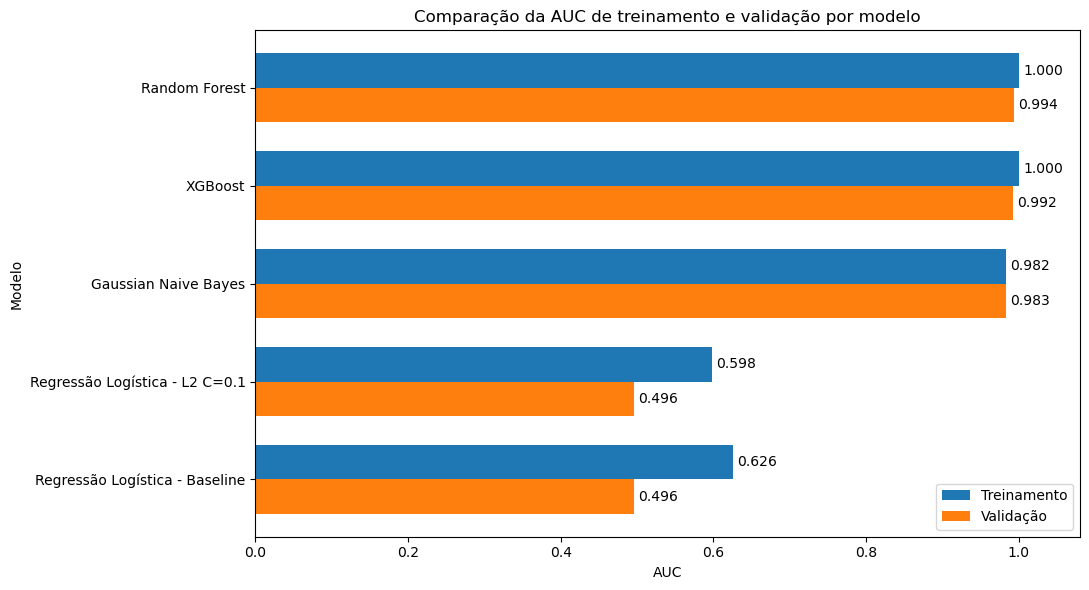

In [34]:

# Organizando as AUCs de treinamento e validação
df_auc = (
    df_metricas
    .pivot(
        index="Modelo",
        columns="Conjunto",
        values="AUC"
    )
    .reset_index()
    .sort_values(
        by="Validação",
        ascending=False
    )
    .reset_index(drop=True)
)

# Posições dos modelos no eixo Y
posicoes = np.arange(len(df_auc))

# Altura de cada barra
altura = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

# Barras de treinamento
barras_treino = ax.barh(
    posicoes - altura / 2,
    df_auc["Treinamento"],
    height=altura,
    label="Treinamento"
)

# Barras de validação
barras_validacao = ax.barh(
    posicoes + altura / 2,
    df_auc["Validação"],
    height=altura,
    label="Validação"
)

# Configuração dos eixos
ax.set_yticks(posicoes)
ax.set_yticklabels(df_auc["Modelo"])

ax.set_xlabel("AUC")
ax.set_ylabel("Modelo")

ax.set_title(
    "Comparação da AUC de treinamento e validação por modelo"
)

ax.set_xlim(0, 1.08)
ax.legend()

# Colocando os valores sobre as barras
ax.bar_label(
    barras_treino,
    fmt="%.3f",
    padding=3
)

ax.bar_label(
    barras_validacao,
    fmt="%.3f",
    padding=3
)

# Melhor modelo no topo
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Otimização e validação cruzada do modelo selecionado

Após a comparação dos modelos, o Random Forest foi selecionado para a etapa de otimização por apresentar a maior AUC no conjunto de validação, com valor de 0,9941, além do maior recall entre os modelos avaliados.

Embora o resultado de validação tenha sido elevado, o modelo apresentou desempenho perfeito no conjunto de treinamento. Esse comportamento indica uma elevada capacidade de ajuste e pode representar um possível aprendizado excessivo de características específicas dos dados de treinamento.

Dessa forma, será realizada a otimização dos hiperparâmetros do Random Forest. O objetivo dessa etapa não é apenas aumentar a AUC, que já se encontra próxima do valor máximo, mas também controlar a complexidade das árvores, reduzir o risco de sobreajuste e preservar o desempenho em dados não utilizados durante o treinamento.

Entre os hiperparâmetros avaliados estarão a quantidade de árvores, a profundidade máxima, a quantidade mínima de observações necessária para realizar uma divisão, a quantidade mínima de observações em cada folha e a quantidade de variáveis consideradas em cada divisão.

Para tornar o processo computacionalmente mais eficiente, será utilizada uma busca aleatória de hiperparâmetros. Essa abordagem testa uma quantidade determinada de combinações, evitando o custo de avaliar exaustivamente todas as possibilidades.

A seleção das melhores configurações será realizada com base na AUC média obtida por validação cruzada estratificada. Nesse procedimento, os dados de treinamento serão divididos em diferentes partes, preservando aproximadamente a proporção das classes em cada divisão.

Cada combinação de hiperparâmetros será treinada e avaliada em diferentes subconjuntos dos dados. Com isso, será possível verificar se o desempenho elevado do Random Forest se mantém de maneira consistente, em vez de depender apenas de uma divisão específica entre treinamento e validação.

Além da AUC média, será analisado o desvio-padrão das pontuações obtidas nos diferentes folds. Uma AUC média elevada acompanhada de um desvio-padrão baixo indicará que o modelo apresenta desempenho consistente e maior capacidade de generalização.

Após a seleção dos melhores hiperparâmetros, o modelo otimizado será novamente avaliado no conjunto de validação. Serão comparadas as métricas AUC, acurácia, recall, precisão e especificidade com os resultados da versão inicial do Random Forest.

Considerando que a AUC inicial já é muito elevada, uma eventual redução pequena nessa métrica poderá ser aceitável caso o modelo otimizado apresente menor diferença entre treinamento e validação, menor complexidade e maior estabilidade na validação cruzada.


In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

# Modelo base
rfc_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Espaço de hiperparâmetros
parametros_rfc = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "bootstrap": [True, False],
    "class_weight": [None, "balanced"]
}

# Validação cruzada estratificada
cv_estratificada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Busca aleatória
random_search_rfc = RandomizedSearchCV(
    estimator=rfc_base,
    param_distributions=parametros_rfc,
    n_iter=30,
    scoring="roc_auc",
    cv=cv_estratificada,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
    refit=True
)

# A busca deve ser ajustada somente nos dados de treinamento
random_search_rfc.fit(
    x_treino_tf,
    y_treino
)

print("Melhores hiperparâmetros:")
print(random_search_rfc.best_params_)

print(
    "\nMelhor AUC média na validação cruzada:",
    round(random_search_rfc.best_score_, 4)
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Melhores hiperparâmetros:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'class_weight': None, 'bootstrap': True}

Melhor AUC média na validação cruzada: 0.9936


In [37]:
# Melhor modelo encontrado
rfc_otimizado = random_search_rfc.best_estimator_

# Probabilidades
y_train_preds_rfc_otimizado = (
    rfc_otimizado.predict_proba(x_treino_tf)[:, 1]
)

y_valid_preds_rfc_otimizado = (
    rfc_otimizado.predict_proba(x_valid_tf)[:, 1]
)

print("Random Forest otimizado")

print("\nTreinamento")

(
    rfc_opt_acuracia_treino,
    rfc_opt_auc_treino,
    rfc_opt_recall_treino,
    rfc_opt_precisao_treino,
    rfc_opt_especificidade_treino
) = print_relatorio(
    y_treino,
    y_train_preds_rfc_otimizado,
    thresh
)

print("\nValidação")

(
    rfc_opt_acuracia_validacao,
    rfc_opt_auc_validacao,
    rfc_opt_recall_validacao,
    rfc_opt_precisao_validacao,
    rfc_opt_especificidade_validacao
) = print_relatorio(
    y_valid,
    y_valid_preds_rfc_otimizado,
    thresh
)

Random Forest otimizado

Treinamento
AUC:             1.000
Acurácia:        0.998
Recall:          0.996
Precisão:        1.000
Especificidade:  1.000
 

Validação
AUC:             0.994
Acurácia:        0.960
Recall:          0.974
Precisão:        0.849
Especificidade:  0.956
 


In [38]:

resultados_cv = pd.DataFrame(
    random_search_rfc.cv_results_
)

melhor_indice = random_search_rfc.best_index_

auc_cv_media = resultados_cv.loc[
    melhor_indice,
    "mean_test_score"
]

auc_cv_desvio = resultados_cv.loc[
    melhor_indice,
    "std_test_score"
]

auc_cv_treino = resultados_cv.loc[
    melhor_indice,
    "mean_train_score"
]

print(f"AUC média de treino no CV: {auc_cv_treino:.4f}")
print(f"AUC média de validação no CV: {auc_cv_media:.4f}")
print(f"Desvio-padrão da AUC no CV: {auc_cv_desvio:.4f}")

AUC média de treino no CV: 1.0000
AUC média de validação no CV: 0.9936
Desvio-padrão da AUC no CV: 0.0022


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

cv_estratificada = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metricas = {
    "auc": "roc_auc",
    "acuracia": "accuracy",
    "recall": "recall",
    "precisao": "precision"
}

rfc_padrao = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

resultado_padrao = cross_validate(
    rfc_padrao,
    x_treino_tf,
    y_treino,
    cv=cv_estratificada,
    scoring=metricas,
    n_jobs=-1
)

for metrica in metricas:
    valores = resultado_padrao[f"test_{metrica}"]

    print(
        f"{metrica}: "
        f"{valores.mean():.4f} ± {valores.std():.4f}"
    )

auc: 0.9945 ± 0.0016
acuracia: 0.9615 ± 0.0056
recall: 0.9766 ± 0.0080
precisao: 0.9481 ± 0.0110


### Comparação entre o Random Forest padrão e o modelo otimizado

Para verificar se a otimização dos hiperparâmetros trouxe ganhos reais de generalização, o Random Forest com parâmetros padrão também foi avaliado por validação cruzada estratificada, utilizando os mesmos folds empregados na etapa de otimização.

O Random Forest padrão apresentou AUC média de 0,9945, com desvio-padrão de 0,0016. O modelo otimizado, por sua vez, apresentou AUC média de 0,9936, com desvio-padrão de 0,0022.

Os resultados mostram que a otimização não aumentou a capacidade de discriminação do modelo. O Random Forest padrão apresentou uma AUC média ligeiramente superior e menor variação entre os folds, indicando desempenho pelo menos tão estável quanto o modelo otimizado.

O modelo padrão também apresentou acurácia média de 0,9615, recall médio de 0,9766 e precisão média de 0,9481 durante a validação cruzada.

Embora o modelo otimizado tenha apresentado melhora de precisão e especificidade em uma divisão específica de validação, essas diferenças não foram acompanhadas por aumento da AUC média na validação cruzada. Portanto, não há evidência suficiente de que o ganho observado compense o aumento da complexidade e o custo computacional da otimização.

Diante desses resultados, o Random Forest com parâmetros padrão foi mantido como modelo final. Essa escolha segue o princípio da parcimônia: quando dois modelos apresentam desempenhos semelhantes, deve-se priorizar aquele que possui menor complexidade, menor custo computacional e maior facilidade de implementação e manutenção.

A busca de hiperparâmetros continua sendo uma etapa relevante, pois permitiu confirmar que o desempenho elevado do modelo padrão não dependia de uma configuração inadequada. Entretanto, neste caso, a otimização não produziu ganho suficiente para justificar a substituição do modelo original.


### Salvando o Modelo

In [68]:
pickle.dump(modelo_v5, open('modelos/melhor_modelo.pkl', 'wb'), protocol = 4)

### Avaliação Final do Melhor Modelo

In [76]:
# Carregando Modelo escolhido

best_model = pickle.load(open('modelos/melhor_modelo.pkl','rb'))
cols_input = pickle.load(open('dados/colunas_entrada.sav','rb'))
scaler = pickle.load(open('dados/scaler.sav','rb'))

# Carregando datasets
df_train = pd.read_csv('dados/dados_treino.csv')
df_valid = pd.read_csv('dados/dados_valid.csv')
df_teste = pd.read_csv('dados/dados_teste.csv')


# Gerando Matrizes
X_train = df_train[cols_input].values
X_valid = df_valid[cols_input].values
X_test = df_teste[cols_input].values

# Gerando targer

y_train = df_train['LABEL_TARGET'].values
y_valid = df_valid['LABEL_TARGET'].values
y_test = df_teste['LABEL_TARGET'].values

# Aplicando Transformação Dados (scaler)

X_train_tf = scaler.transform(X_train)
X_valid_tf = scaler.transform(X_valid)
X_test_tf = scaler.transform(X_test)

In [78]:
# Previsões Modelo
y_train_preds = best_model.predict_proba(X_train_tf)[:,1]
y_valid_preds = best_model.predict_proba(X_valid_tf)[:,1]
y_test_preds = best_model.predict_proba(X_test_tf)[:,1]


In [82]:
# Limiar de classificação
thresh = 0.5


# =========================
# Métricas de treinamento
# =========================

print("\nTreinamento")

(
    acuracia_treinamento,
    auc_treinamento,
    recall_treinamento,
    precisao_treinamento,
    especificidade_treinamento
) = print_relatorio(
    y_train,
    y_train_preds,
    thresh
)


# ===================
# Métricas de teste
# ===================

print("\nTeste")

(
    acuracia_teste,
    auc_teste,
    recall_teste,
    precisao_teste,
    especificidade_teste
) = print_relatorio(
    y_test,
    y_test_preds,
    thresh
)


# =======================
# Métricas de validação
# =======================

print("\nValidação")

(
    acuracia_validacao,
    auc_validacao,
    recall_validacao,
    precisao_validacao,
    especificidade_validacao
) = print_relatorio(
    y_valid,
    y_valid_preds,
    thresh
)


Treinamento
AUC:             0.999
Acurácia:        0.966
Recall:          1.000
Precisão:        0.856
Especificidade:  0.956
 

Teste
AUC:             0.994
Acurácia:        0.950
Recall:          0.986
Precisão:        0.809
Especificidade:  0.936
 

Validação
AUC:             0.996
Acurácia:        0.963
Recall:          0.991
Precisão:        0.843
Especificidade:  0.950
 


###  Calcula a curva ROC


Resultado da AUC
AUC Treinamento: 0.9993
AUC Teste:       0.9938
AUC Validação:   0.9961


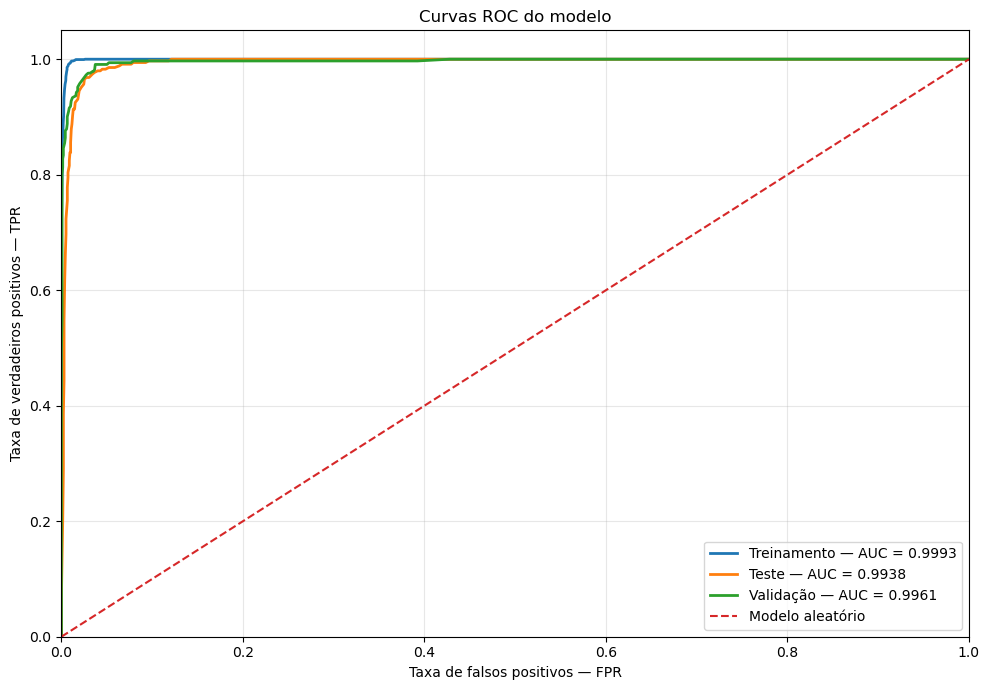

In [85]:
# ==========================================================
# Previsões do modelo
# ==========================================================

y_train_preds = best_model.predict_proba(X_train_tf)[:, 1]
y_valid_preds = best_model.predict_proba(X_valid_tf)[:, 1]
y_test_preds = best_model.predict_proba(X_test_tf)[:, 1]


# ==========================================================
# Curvas ROC
# ==========================================================


# Treinamento
fpr_train, tpr_train, thresholds_train = roc_curve(
    y_train,
    y_train_preds
)

auc_train = roc_auc_score(
    y_train,
    y_train_preds
)


# Teste
fpr_test, tpr_test, thresholds_test = roc_curve(
    y_test,
    y_test_preds
)

auc_test = roc_auc_score(
    y_test,
    y_test_preds
)


# Validação
fpr_valid, tpr_valid, thresholds_valid = roc_curve(
    y_valid,
    y_valid_preds
)

auc_valid = roc_auc_score(
    y_valid,
    y_valid_preds
)


# Resultados
print("\nResultado da AUC")

print(f"AUC Treinamento: {auc_train:.4f}")
print(f"AUC Teste:       {auc_test:.4f}")
print(f"AUC Validação:   {auc_valid:.4f}")


# Gráfico
plt.figure(figsize=(10, 7))

plt.plot(
    fpr_train,
    tpr_train,
    linewidth=2,
    label=f"Treinamento — AUC = {auc_train:.4f}"
)

plt.plot(
    fpr_test,
    tpr_test,
    linewidth=2,
    label=f"Teste — AUC = {auc_test:.4f}"
)

plt.plot(
    fpr_valid,
    tpr_valid,
    linewidth=2,
    label=f"Validação — AUC = {auc_valid:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Modelo aleatório"
)

plt.title("Curvas ROC do modelo")
plt.xlabel("Taxa de falsos positivos — FPR")
plt.ylabel("Taxa de verdadeiros positivos — TPR")

plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## Conclusão

Este projeto teve como objetivo desenvolver e avaliar modelos de classificação capazes de prever o evento de interesse por meio de técnicas de Machine Learning, buscando não apenas alto desempenho preditivo, mas também boa capacidade de generalização.

Foram comparados diferentes algoritmos, sendo o **Random Forest** o modelo que apresentou o melhor equilíbrio entre as métricas de desempenho ao longo do processo de avaliação. Em seguida, foi realizada uma etapa de otimização de hiperparâmetros utilizando **Randomized Search** combinado com **Validação Cruzada Estratificada**, permitindo verificar se seria possível obter ganhos adicionais de desempenho.

Embora o modelo otimizado tenha apresentado pequenas melhorias em métricas específicas em uma única divisão de validação, a validação cruzada mostrou que o **Random Forest com parâmetros padrão** manteve desempenho ligeiramente superior em termos de AUC média, além de apresentar menor variabilidade entre os folds. Esses resultados indicam que a otimização não trouxe ganhos consistentes de generalização capazes de justificar o aumento da complexidade do modelo.

Dessa forma, o Random Forest padrão foi selecionado como modelo final, seguindo o princípio da parcimônia, que recomenda priorizar soluções mais simples quando apresentam desempenho equivalente ou superior às alternativas mais complexas.

Além da construção do modelo, este projeto reforçou a importância de um fluxo completo de desenvolvimento em Machine Learning, incluindo comparação entre algoritmos, otimização de hiperparâmetros, validação cruzada, análise de métricas e avaliação crítica dos resultados. Mais do que obter alta acurácia, o processo demonstrou que a escolha de um modelo deve considerar também sua estabilidade, capacidade de generalização, custo computacional e facilidade de manutenção.

Os resultados obtidos evidenciam que técnicas de validação são fundamentais para reduzir o risco de overfitting e apoiar a seleção de modelos mais robustos, tornando o processo de tomada de decisão mais confiável para aplicações reais de Ciência de Dados.
